In [1]:
import sys
sys.path.append('..')
import pandas as pd
import datetime as dt
import EvaluationFunctions as eva
import StockPrices.StockFetcher as Fetcher
import matplotlib.pyplot as plt
import seaborn as sb

ModuleNotFoundError: No module named 'yfinance'

# Modify fields here based on what needs to be evaluated

In [3]:
data = pd.read_csv("../ProcessedPortfolio.csv") # Portfolio with Ticker and Exchange columns
portfolio_stocks = Fetcher.prepare_tickers(data["Ticker"].to_list(), data["Exchange"].to_list())

end = dt.date.today() # Fetches stock values from today
start = end - dt.timedelta(days=1*365) # Up until x days in the past

market_ticker = "^GSPC" # For beta calculation

extra_tickers = ["VEEV", "NVO", "ISRG"] # Stocks to evaluate
extra_tickers_exchange = ["", "", ""] # Exchanges of each stock to evaluate (if USA exchange not necessary)
ticker_sector = ["","",""]
assert len(extra_tickers) == len(extra_tickers_exchange)
assert len(extra_tickers) == len(ticker_sector)

## Data preparation

In [4]:
port_closes, nf = Fetcher.get_stock_prices(Fetcher.prepare_tickers(data["Ticker"].tolist() + [market_ticker], 
                                                              data["Exchange"].tolist() + [""]), start, end, True)

print("Could not find stocks:", nf)

Could not find stocks: []


In [5]:
pitch_closes, nf = Fetcher.get_stock_prices(Fetcher.prepare_tickers(extra_tickers, extra_tickers_exchange ), start, end, True)

print("Could not find stocks:", nf)

Could not find stocks: []


In [6]:
closes = pd.merge(port_closes.reset_index(), pitch_closes.reset_index()).set_index("Date")

In [7]:
mean_industry_weights = data.groupby("Sector").mean()["Weight in Portofolio "]
ticker_weights = []
for i in range(0, len(extra_tickers)):
    if ticker_sector is not None and ticker_sector[i]!= "":
        ticker_weights.append(mean_industry_weights[ticker_sector[i]])
    else:
        ticker_weights.append(mean_industry_weights.mean())

## Compute metrics

In [8]:
res = eva.evaluate(closes=closes, weights=data['Weight in Portofolio '], tickers=extra_tickers, ticker_weights=ticker_weights, market_ticker=market_ticker)
res.keys()

dict_keys(['log returns', 'log returns correlation', 'Sharpe ratio', 'Sortino ratio', 'Beta', 'Inc Var'])

## Tabulate results
Inc Var still needs to get tabulated

In [9]:
# Tabulate the results:
r = pd.DataFrame()
for key in res:
    if key == "log returns" or key=="Inc Var":
        continue
    if isinstance(res[key], pd.DataFrame):
        r = pd.concat([r, res[key]])
    else:
        r.insert(0, key, res[key])
r = r.reset_index().rename(columns={"Symbols":"Tickers"}).set_index("Tickers").transpose()
r.transpose().head()

Symbols,Beta,Sortino ratio,Sharpe ratio,Portfolio,AD.AS,KER.PA,LOW,TGT,WBD,MA,...,SAPA.F,TCEHY,GOOG,0992.HK,META,DELL,^GSPC,VEEV,NVO,ISRG
Tickers,,,,,,,,,,,,,,,,,,,,,
VEEV,1.265265,-0.080602,-0.058665,0.535579,0.029284,0.271338,0.477778,0.387320,0.321987,0.473484,...,0.176745,0.396272,0.533550,0.079068,0.448562,0.375498,0.611074,1.000000,0.333459,0.556575
NVO,0.571117,0.025015,0.019720,0.362604,0.143516,0.155876,0.237414,0.197786,0.166294,0.311004,...,0.084175,0.178882,0.306419,0.033612,0.260686,0.211945,0.396798,0.333459,1.000000,0.311200
ISRG,1.427118,-0.044889,-0.033090,0.683495,0.102063,0.357008,0.495102,0.440133,0.399742,0.640601,...,0.196303,0.317039,0.658852,0.135299,0.483424,0.488033,0.767045,0.556575,0.311200,1.000000


In [10]:
r.to_csv(str(end)+"-"+"_".join(extra_tickers)+"-Evaluation.csv")

## Log return correlations

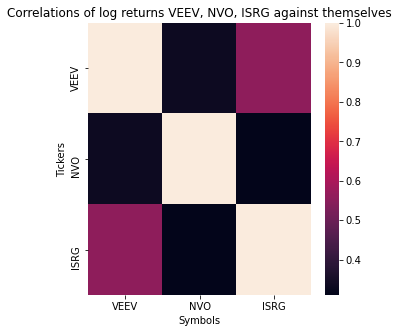

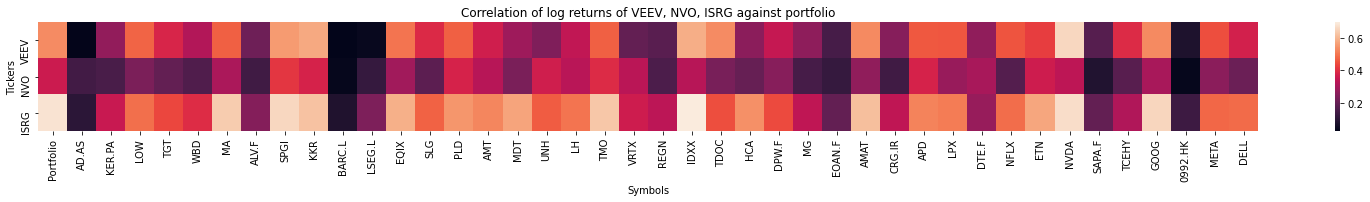

In [11]:
sizeRatio = len(extra_tickers)/len(extra_tickers)
size = 5
fig = plt.figure(figsize=(sizeRatio*size, size))
heat_plot = sb.heatmap(r.transpose()[extra_tickers])
plt.title("Correlations of log returns "+", ".join(extra_tickers)+" against themselves")
plt.show()

sizeRatio = len(portfolio_stocks)/len(extra_tickers)
size = 2
fig = plt.figure(figsize=(sizeRatio*size, size))
heat_plot = sb.heatmap(r.transpose()[["Portfolio"]+portfolio_stocks])
plt.title("Correlation of log returns of "+", ".join(extra_tickers)+" against portfolio")
plt.show()

## Ratios and Beta

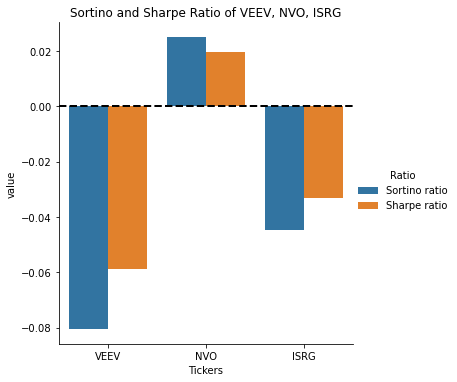

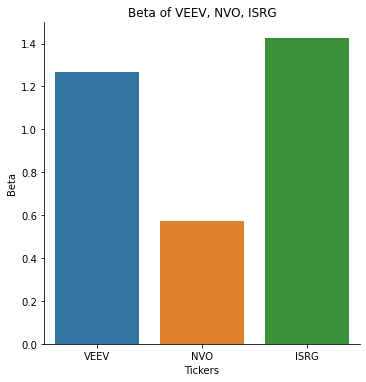

In [12]:
tidy = r.transpose()[["Sortino ratio", "Sharpe ratio"]].reset_index()
tidy = pd.melt(tidy, id_vars="Tickers", var_name="Ratio", value_name="value")
g = sb.catplot(x='Tickers', y='value', hue='Ratio', data=tidy, kind='bar')
g.axes[0][0].axhline(y = 0, color='black', ls='--', lw=2)
plt.title("Sortino and Sharpe Ratio of "+", ".join(extra_tickers))
plt.show()

tidy = r.transpose()[["Beta"]].reset_index()
g = sb.catplot(x='Tickers', y='Beta', data=tidy, kind='bar')
plt.title("Beta of "+", ".join(extra_tickers))
plt.show()

## Incremental VaR

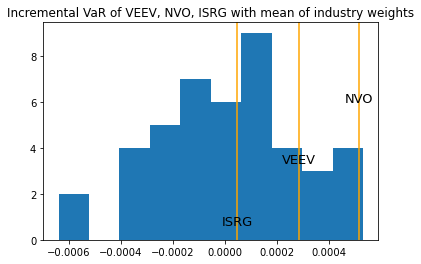

In [13]:
plt.hist(res["Inc Var"]["Incremental VaR"])
inc_var_extra = res["Inc Var"][res["Inc Var"]["Stock"].isin(extra_tickers)].sort_values(by="Incremental VaR")

biggestBin = 8
steps = biggestBin / len(extra_tickers)
for idx, xc in inc_var_extra.reset_index(drop=True).iterrows():

    plt.axvline(x=xc["Incremental VaR"], color="orange")
    print()
    plt.text(xc["Incremental VaR"], biggestBin*0.1+steps*idx ,xc["Stock"], color="black", size=13, ha='center', va='center')
plt.title("Incremental VaR of "+", ".join(extra_tickers)+" with mean of industry weights")
plt.show()